In [1]:
# Import core packages for data manipulation and visualization
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
import matplotlib
plt.style.use('ggplot')
from matplotlib.pyplot import figure

# Configure notebook to display charts directly inline
%matplotlib inline
matplotlib.rcParams['figure.figsize'] = (7,5)

# Suppress minor package warnings for cleaner output
pd.options.mode.chained_assignment = None


# Load the video game sales dataset from the local drive
df = pd.read_csv(r'C:\Data\vgsales.csv')

In [2]:
# Display the first 5 records to verify structure and content
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [3]:
# Scan the dataset to detect the percentage of missing values in each column

for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

Rank - 0%
Name - 0%
Platform - 0%
Year - 2%
Genre - 0%
Publisher - 0%
NA_Sales - 0%
EU_Sales - 0%
JP_Sales - 0%
Other_Sales - 0%
Global_Sales - 0%


In [4]:
# Clean up the dataset by handling missing values and correcting data types

df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype('int64')
df.head(3)

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82


In [5]:
# Data Types for our columns

print(df.dtypes)

Rank              int64
Name                str
Platform            str
Year              int64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object


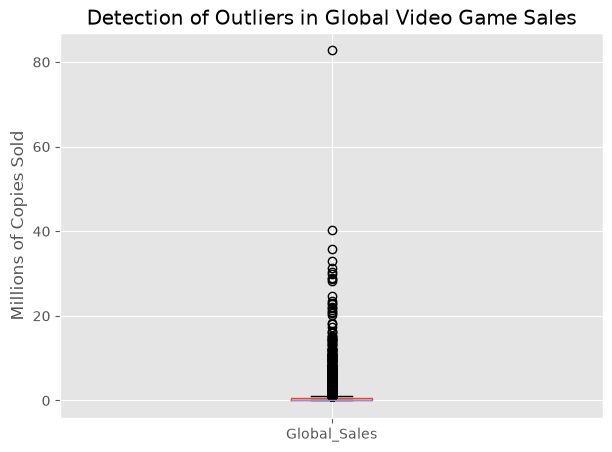

In [6]:
# Check for extreme outlier hits in the global video game sales market
df.boxplot(column=['Global_Sales'])
plt.title('Detection of Outliers in Global Video Game Sales')
plt.ylabel('Millions of Copies Sold')

plt.show()


In [7]:
df = df.drop_duplicates()
df.shape

(16327, 11)

In [8]:
# Sort the video game dataset in descending order to see top global sellers
df.sort_values(by=['Global_Sales'], inplace=False, ascending=False)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


Text(0, 0.5, 'Global Sales (Millions)')

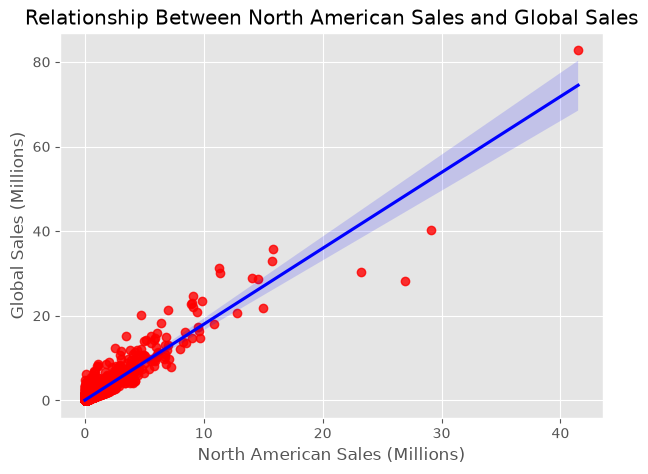

In [9]:
# Plot Regional Sales against Global Sales to visualize the linear relationship
sns.regplot(x="NA_Sales", y="Global_Sales", data=df, scatter_kws={"color": "red"}, line_kws={"color": "blue"})

plt.title('Relationship Between North American Sales and Global Sales')
plt.xlabel('North American Sales (Millions)')
plt.ylabel('Global Sales (Millions)')



Text(0, 0.5, 'Global Sales (Millions of Copies)')

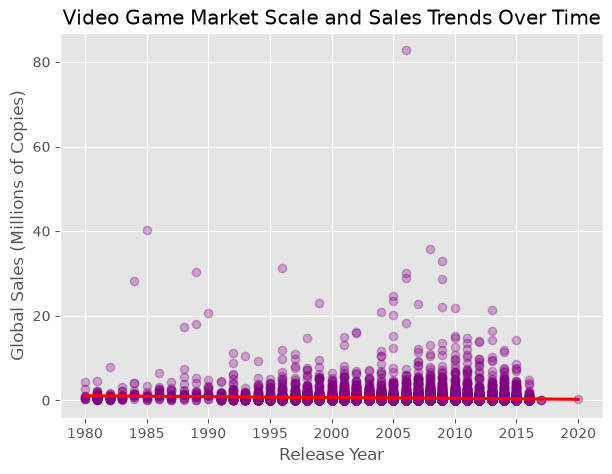

In [10]:
# Plot the release year against global sales to visualize market growth over time
sns.regplot(x="Year", y="Global_Sales", data=df, scatter_kws={"color": "purple", "alpha": 0.3}, line_kws={"color": "red"})

# Add professional labels for presentation
plt.title('Video Game Market Scale and Sales Trends Over Time')
plt.xlabel('Release Year')
plt.ylabel('Global Sales (Millions of Copies)')

In [11]:
# Correlation Matrix between all numeric columns
df.corr(method='pearson', numeric_only=True)


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Rank,1.000000,0.178814,-0.400328,-0.379024,-0.269138,-0.332521,-0.426880
Year,0.178814,1.000000,-0.091402,0.006014,-0.169316,0.041058,-0.074735
NA_Sales,-0.400328,-0.091402,1.000000,0.768936,0.451285,0.634508,0.941268
EU_Sales,-0.379024,0.006014,0.768936,1.000000,0.436414,0.726266,0.903271
JP_Sales,-0.269138,-0.169316,0.451285,0.436414,1.000000,0.290653,0.612794
Other_Sales,-0.332521,0.041058,0.634508,0.726266,0.290653,1.000000,0.747974
Global_Sales,-0.426880,-0.074735,0.941268,0.903271,0.612794,0.747974,1.000000


In [14]:
df.corr(method='kendall', numeric_only=True)

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Rank,1.000000,0.104901,-0.669188,-0.556806,-0.127376,-0.677846,-0.989774
Year,0.104901,1.000000,-0.094939,-0.047794,0.013893,0.041790,-0.105730
NA_Sales,-0.669188,-0.094939,1.000000,0.558131,-0.179471,0.642030,0.675418
EU_Sales,-0.556806,-0.047794,0.558131,1.000000,-0.142351,0.661738,0.561887
JP_Sales,-0.127376,0.013893,-0.179471,-0.142351,1.000000,-0.058309,0.128730
Other_Sales,-0.677846,0.041790,0.642030,0.661738,-0.058309,1.000000,0.684433
Global_Sales,-0.989774,-0.105730,0.675418,0.561887,0.128730,0.684433,1.000000


In [15]:
df.corr(method='spearman', numeric_only=True)


,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Rank,1.000000,0.151529,-0.795144,-0.697022,-0.154627,-0.810794,-0.999624
Year,0.151529,1.000000,-0.133088,-0.057729,0.009605,0.055726,-0.151248
NA_Sales,-0.795144,-0.133088,1.000000,0.683272,-0.226471,0.771415,0.795185
EU_Sales,-0.697022,-0.057729,0.683272,1.000000,-0.176470,0.766460,0.696765
JP_Sales,-0.154627,0.009605,-0.226471,-0.176470,1.000000,-0.069295,0.154737
Other_Sales,-0.810794,0.055726,0.771415,0.766460,-0.069295,1.000000,0.810769
Global_Sales,-0.999624,-0.151248,0.795185,0.696765,0.154737,0.810769,1.000000


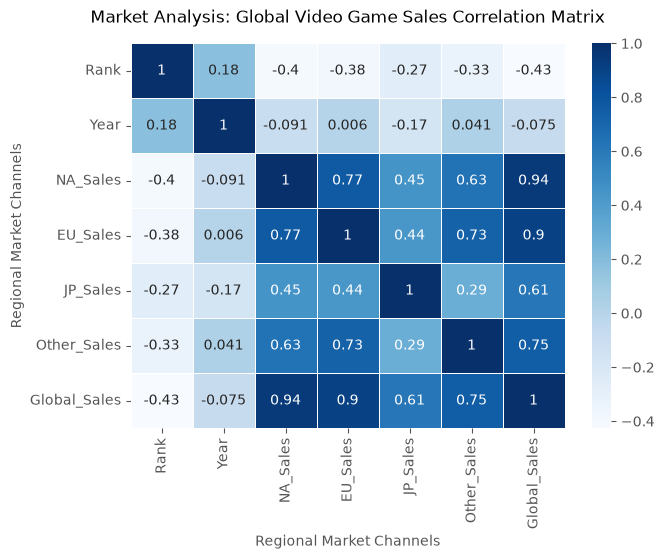

In [16]:

correlation_matrix = df.corr(method='pearson', numeric_only=True)

# Generate the visual heatmap matrix 
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', linewidths=0.5)


plt.title('Market Analysis: Global Video Game Sales Correlation Matrix', fontsize=12, pad=15)
plt.xlabel('Regional Market Channels', fontsize=10)
plt.ylabel('Regional Market Channels', fontsize=10)

plt.show()

In [17]:
# Applying factorization to assign numerical codes to categorical string data (Platform, Genre, Publisher)
categorical_correlation = df.apply(lambda x: x.factorize()[0]).corr(method='pearson')

# Display the complete combined matrix
categorical_correlation



,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Rank,1.000000,0.878635,0.146724,-0.043807,0.142316,0.427589,-0.209112,-0.348254,-0.185546,-0.004464,0.663033
Name,0.878635,1.000000,0.054450,-0.050048,0.166791,0.471854,-0.227197,-0.350658,-0.129266,-0.036946,0.572653
Platform,0.146724,0.054450,1.000000,0.315022,0.058550,0.088263,-0.091384,0.028504,0.004377,-0.048730,0.104310
Year,-0.043807,-0.050048,0.315022,1.000000,-0.011953,0.013432,-0.034357,0.104250,0.071169,-0.027220,-0.031720
Genre,0.142316,0.166791,0.058550,-0.011953,1.000000,0.141251,-0.083571,-0.040304,-0.015251,-0.026470,0.080689
Publisher,0.427589,0.471854,0.088263,0.013432,0.141251,1.000000,-0.168595,-0.178818,-0.042461,-0.070613,0.230814
NA_Sales,-0.209112,-0.227197,-0.091384,-0.034357,-0.083571,-0.168595,1.000000,0.230151,-0.104295,0.237683,0.122301
EU_Sales,-0.348254,-0.350658,0.028504,0.104250,-0.040304,-0.178818,0.230151,1.000000,-0.051181,0.253639,-0.018831
JP_Sales,-0.185546,-0.129266,0.004377,0.071169,-0.015251,-0.042461,-0.104295,-0.051181,1.000000,-0.039003,-0.135262
Other_Sales,-0.004464,-0.036946,-0.048730,-0.027220,-0.026470,-0.070613,0.237683,0.253639,-0.039003,1.000000,0.338871


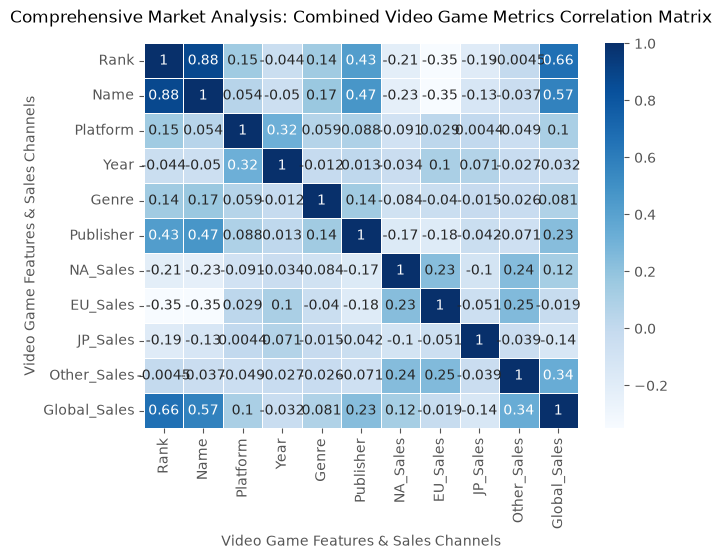

In [18]:
# Apply factorization to look for correlations across both numeric sales and text categories
correlation_matrix = df.apply(lambda x: x.factorize()[0]).corr(method='pearson')

sns.heatmap(correlation_matrix, annot=True, cmap='Blues', linewidths=0.5)

plt.title('Comprehensive Market Analysis: Combined Video Game Metrics Correlation Matrix', fontsize=12, pad=15)
plt.xlabel('Video Game Features & Sales Channels', fontsize=10)
plt.ylabel('Video Game Features & Sales Channels', fontsize=10)

plt.show()


In [19]:
# Unstack the comprehensive correlation matrix into a single vertical list of pairs
correlation_mat = df.apply(lambda x: x.factorize()[0]).corr()
corr_pairs = correlation_mat.unstack()

print(corr_pairs)


Rank          Rank            1.000000
              Name            0.878635
              Platform        0.146724
              Year           -0.043807
              Genre           0.142316
                                ...   
Global_Sales  NA_Sales        0.122301
              EU_Sales       -0.018831
              JP_Sales       -0.135262
              Other_Sales     0.338871
              Global_Sales    1.000000
Length: 121, dtype: float64


In [20]:
# Apply an ascending quicksort to the paired feature vectors.
sorted_pairs = corr_pairs.sort_values(kind="quicksort")
print(sorted_pairs)

Name          EU_Sales       -0.350658
EU_Sales      Name           -0.350658
              Rank           -0.348254
Rank          EU_Sales       -0.348254
Name          NA_Sales       -0.227197
                                ...   
EU_Sales      EU_Sales        1.000000
NA_Sales      NA_Sales        1.000000
Other_Sales   Other_Sales     1.000000
JP_Sales      JP_Sales        1.000000
Global_Sales  Global_Sales    1.000000
Length: 121, dtype: float64


In [21]:
# absolute value filter to isolate high-variance, non-trivial relationships.
strong_market_pairs = sorted_pairs[abs(sorted_pairs) > 0.5]
print(strong_market_pairs)

Global_Sales  Name            0.572653
Name          Global_Sales    0.572653
Rank          Global_Sales    0.663033
Global_Sales  Rank            0.663033
Rank          Name            0.878635
Name          Rank            0.878635
              Name            1.000000
Rank          Rank            1.000000
Publisher     Publisher       1.000000
Genre         Genre           1.000000
Year          Year            1.000000
Platform      Platform        1.000000
EU_Sales      EU_Sales        1.000000
NA_Sales      NA_Sales        1.000000
Other_Sales   Other_Sales     1.000000
JP_Sales      JP_Sales        1.000000
Global_Sales  Global_Sales    1.000000
dtype: float64


In [22]:
#Top 15 publishers by total global sales volume
publisher_global_sales = df.groupby('Publisher')[['Global_Sales']].sum()
top_15_publishers = publisher_global_sales.sort_values('Global_Sales', ascending=False)[:15]
top_15_publishers_cleaned = top_15_publishers['Global_Sales'].astype('int64')
top_15_publishers_cleaned


Publisher
Nintendo                                  1784
Electronic Arts                           1093
Activision                                 721
Sony Computer Entertainment                607
Ubisoft                                    473
Take-Two Interactive                       399
THQ                                        340
Konami Digital Entertainment               278
Sega                                       270
Namco Bandai Games                         253
Microsoft Game Studios                     245
Capcom                                     199
Atari                                      146
Square Enix                                144
Warner Bros. Interactive Entertainment     142
Name: Global_Sales, dtype: int64

In [23]:
# Standardize the release year column by converting numeric records to clean strings
df['Year'] = df['Year'].astype(str).str[:4]
df


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [24]:
# chronological global sales volume grouped by corporate publisher and release year
df.groupby(['Publisher', 'Year'])[['Global_Sales']].sum()


Global_Sales
Publisher                    Year              
10TACLE Studios              2006          0.02
                             2007          0.09
1C Company                   2009          0.01
                             2011          0.09
20th Century Fox Video Games 1981          1.35
...                                         ...
imageepoch Inc.              2014          0.04
inXile Entertainment         2015          0.10
mixi, Inc                    2015          0.86
responDESIGN                 2004          0.09
                             2005          0.04

[2321 rows x 1 columns]

In [26]:
# Ranking the top 15 publisher-year segments by combined global sales volume
PublisherYearSales = df.groupby(['Publisher', 'Year'])[['Global_Sales']].sum()

PublisherYearSalesSorted = PublisherYearSales.sort_values(['Global_Sales', 'Publisher', 'Year'], ascending=False)[:15]

PublisherYearSalesSortedClean = PublisherYearSalesSorted['Global_Sales'].astype('int64')

PublisherYearSalesSortedClean


Publisher        Year
Nintendo         2006    205
                 2009    128
                 2005    127
                 2007    104
                 2008     91
Electronic Arts  2009     86
                 2008     84
                 2010     81
Activision       2009     78
Nintendo         1996     73
Electronic Arts  2002     73
                 2011     72
                 2007     71
                 2003     69
Activision       2008     67
Name: Global_Sales, dtype: int64

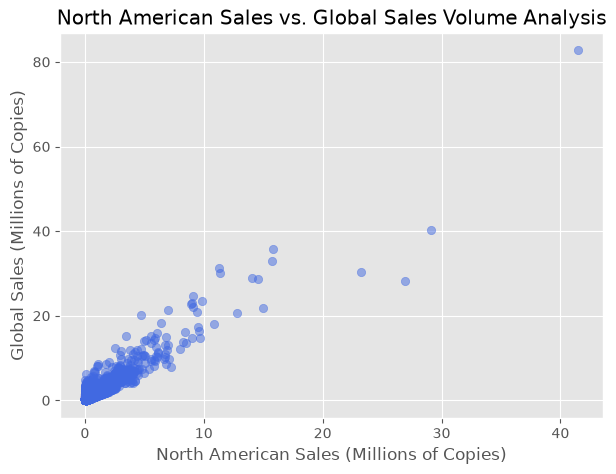

In [28]:
# Generate a scatter plot to analyze structural distribution variance between regional and global sales volume
plt.scatter(x=df['NA_Sales'], y=df['Global_Sales'], alpha=0.5, color='royalblue')

# Apply clean visualization formatting and correct domain context labels
plt.title('North American Sales vs. Global Sales Volume Analysis')
plt.xlabel('North American Sales (Millions of Copies)')
plt.ylabel('Global Sales (Millions of Copies)')

plt.show()


In [29]:
df


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01
